In [ ]:
import pandas as pd
import numpy as np
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTENC

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report

import shap

# Suppress XGBoost environment warnings
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

In [ ]:
df = pd.read_excel('Sleep Data.xlsx')
df.columns = df.columns.str.strip()
df = df[df['Document - ID'].notna()]
print(df.shape, "df shape")
df.head(5)

(159, 92) df shape


,Document - ID,consultant,procedure,ASA,date,RSI,HADS,Insom,ESS,NOSE,...,AirwaySize_chin_lift,AirwaySize_jaw_thrust,trapdoor_epiglottis,P,T,L,Tb,E,simplified_treatment_plan,treatment_plan_with_stages
0,TEXTBOX_003_DISE,"Consultant 1, Consultant 2",SEDATION NASENDOSCOPY (DISE),NaN,17.01.23,13,NaN,5,5-2,1,...,3.0,3,no,1,0,0,0,0,[Rhinitis Rx][Sleep Position Modifier][Allergy...,1.[continue Rhinitis Rx][Sleep Position Modifi...
1,TEXTBOX_006_DISE,Consultant 1,SEDATION NASENDOSCOPY (DISE 4.5),NaN,11.06.25,5,NoField,1,5-1,3,...,2.0,3,normal,1,0,1,1,0,[Weight Loss][Procut Palatoplasty][Barbed Suture],1.[Weight Loss]\n2.[Procut Palatoplasty (anter...
2,TEXTBOX_007_DISE,Consultant 1,SEDATION NASENDOSCOPY (DISE 4.5),2,11.06.25,6,NoField,12,3-1,13,...,NaN,NaN,U-shaped,0,0,0,1,0,[Weight Loss][Rhinitis Rx][Myofunct. Therapy][...,1.Augmentin for pus L OMC [? weight loss][Rhin...
3,TEXTBOX_008_DISE,Consultant 1,SEDATION NASENDOSCOPY (DISE),2,06.12.22,NaN,NaN,NaN,3,NaN,...,2.0,3,NaN,1,0,0,2,0,[Rhinitis Rx][Sleep Position Modifier][Allergy...,1.[Rhinitis Rx][Sleep Position Modifier][Aller...
4,TEXTBOX_009_DISE,Consultant 1,SEDATION NASENDOSCOPY (DISE 4.5),2,28.05.25,6,NoField,5,19-10,0,...,2.0,3,normal,2,0,0,2,0,[Weight Loss][MAD][Chinstrap][Sleep Position M...,1.[Weight Loss] – reduce work on neck at GYM –...


In [ ]:
# treatments are in bracket format, we extract using this function
def extract_treatments(raw_plan_string):
  if pd.isna(raw_plan_string):
    return []
  raw_list = [t.strip() for t in re.findall(r'\[([^\]]+)\]', str(raw_plan_string))]

  cleaned_list = []
  for t in raw_list:
    clean_t = standardize_treatment(t)
    if clean_t:
      cleaned_list.append(clean_t)

  return list(set(cleaned_list))

def standardize_treatment(t):
  s = t.lower().strip()

  if "no rhinitis rx" in s:
    return None

  if "weight" in s or "bariatric" in s:
      return "Weight Loss"
  elif "rhinitis" in s or "douche" in s or "nose spray" in s:
      return "Rhinitis Rx"
  elif "procut" in s or "palatoplasty" in s:
      return "Procut Palatoplasty"
  elif "turbinate" in s or "turbinoplasty" in s or "rf turbs" in s:
      return "RF Turbinates"
  elif "side sleep" in s or "sleep on" in s or "position modifier" in s:
      return "Sleep Position Modifier"
  elif "chinstrap" in s:
      return "Chinstrap"
  elif "allergy" in s or "rast" in s:
      return "Allergy Testing"
  elif "vit" in s:
      return "Vit D"
  elif "reflux" in s or "antacid" in s or "ppi" in s or "gaviscon" in s:
      return "Reflux Advice"
  elif "rpt ss" in s or "sleep study" in s or "sleep q" in s:
      return "Repeat Sleep Study"
  elif "ct sinus" in s:
      return "CT Sinus"
  elif "dise" in s:
      return "Repeat DISE"
  elif "nipf" in s:
      return "NIPF"
  elif "epiglott" in s:
      return "Epiglottopexy"
  elif "mad" in s and "max facs" in s:
      return "MAD by Max Facs"
  elif "mad" in s:
      return "MAD"
  elif "alcohol" in s:
      return "Reduce Alcohol"
  elif "myofunct" in s:
      return "Myofunctional Therapy"
  elif "cbti" in s:
      return "CBTi"
  elif "cpap" in s:
      return "CPAP"
  elif "sleep hygiene" in s:
      return "Sleep Hygiene"
  elif "hypoglossal" in s:
      return "Hypoglossal N. Stimulator"
  elif "tors" in s:
      return "TORS"
  elif "orthognathic" in s:
      return "Orthognathic Surgery"
  elif "lingual tonsil" in s:
      return "Lingual Tonsil Reduction"
  elif "tonsillectomy" in s:
      return "Tonsillectomy"
  elif "adenoidectomy" in s:
      return "Adenoidectomy"
  elif "barbed suture" in s:
      return "Barbed Suture"
  elif "septoplasty" in s:
      return "Septoplasty"
  elif "rf palate" in s:
      return "RF Palate"
  elif "rf bot" in s:
      return "RF BOT"
  elif "mdt" in s:
      return "MDT"
  elif "airgym" in s:
    return "Myofunctional Therapy"
  elif "closed mouth" in s:
    return "Chinstrap"
  elif "septorhinoplasty" in s or "collumelloplasty" in s:
    return "Septoplasty"
  elif "expansion sphincter" in s:
    return "Barbed Suture"

  # NB we drop these (return None so they're excluded):
  elif "salt" in s and ("referral" in s or "assessment" in s):
    return None
  elif "ct soft tissue" in s:
    return None
  elif "2nd stage" in s:
    return None
  elif "fess" in s or "polypectomy" in s:
    return None

  return t.title()
# For each df treatment_plan column, extract plan
all_treatments = set()
for plan in df['simplified_treatment_plan'].dropna():
  all_treatments.update(extract_treatments(plan))

all_treatments = sorted(list(all_treatments))
print(f'all cleaned treatment lenght {len(all_treatments)}')
print(all_treatments)

all cleaned treatment lenght 32
['Adenoidectomy', 'Allergy Testing', 'Barbed Suture', 'CBTi', 'CPAP', 'CT Sinus', 'Chinstrap', 'Epiglottopexy', 'Hypoglossal N. Stimulator', 'Lingual Tonsil Reduction', 'MAD', 'MAD by Max Facs', 'MDT', 'Myofunctional Therapy', 'NIPF', 'Orthognathic Surgery', 'Procut Palatoplasty', 'RF BOT', 'RF Palate', 'RF Turbinates', 'Reduce Alcohol', 'Reflux Advice', 'Repeat DISE', 'Repeat Sleep Study', 'Rhinitis Rx', 'Septoplasty', 'Sleep Hygiene', 'Sleep Position Modifier', 'TORS', 'Tonsillectomy', 'Vit D', 'Weight Loss']


We create a column for each treatment, and for each row in data we input 1 if patient took treatment, 0 if patient didn’t. This is multi label binarisation


In [ ]:
def has_treatment (raw_plan_string, treatment_name):
  return 1 if treatment_name in extract_treatments(raw_plan_string) else 0

label_df = pd.DataFrame(index=df.index)
for treatment in all_treatments:
  label_df[treatment] = df['simplified_treatment_plan'].apply(
      lambda x: has_treatment(x, treatment)
  )
print(f"shape: {label_df.shape}")
label_df.head()

shape: (159, 32)


,Adenoidectomy,Allergy Testing,Barbed Suture,CBTi,CPAP,CT Sinus,Chinstrap,Epiglottopexy,Hypoglossal N. Stimulator,Lingual Tonsil Reduction,...,Repeat DISE,Repeat Sleep Study,Rhinitis Rx,Septoplasty,Sleep Hygiene,Sleep Position Modifier,TORS,Tonsillectomy,Vit D,Weight Loss
0,0,1,0,0,0,0,0,0,0,0,...,0,1,1,1,0,1,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,0,1,0,0,0,1,0,0,0,...,0,0,1,0,0,1,0,0,0,1
3,0,1,0,0,0,0,1,0,0,0,...,0,0,1,1,0,1,0,0,0,0
4,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,1


**Feature Cleaning**

Utililty functions

In [ ]:

def to_float_safe(val):
  try:
    return float(str(val).strip())
  except:
    return np.nan

def extract_first_number(val):
  if pd.isna(val):
    return np.nan
  match = re.search(r'\d+\.?\d*', str(val).strip())
  return float(match.group()) if match else np.nan

def extract_last_number(val):
  if pd.isna(val):
    return np.nan
  matches = re.findall(r'\d+\.?\d*', str(val).strip())
  return float(matches[-1]) if matches else np.nan

def extract_max_number(val):
  if pd.isna(val):
    return np.nan
  matches = re.findall(r'\d+\.?\d*', str(val).strip())
  return max(float(m) for m in matches) if matches else np.nan

def contains_keyword(val, keywords):
  if pd.isna(val):
    return np.nan
  val_to_lowercase = str(val).lower()
  return 1 if any(kw.lower() in val_to_lowercase for kw in keywords) else 0

def roman_to_int(s):
  roman_map = {'I': 1, 'V': 5, 'X': 10, 'L': 50, 'C': 100, 'D': 500, 'M': 1000}
  total = 0
  # Added for use case where numerals have -, we take baseline value
  s = s.split('-')[0]

  for i in range(len(s)):
    # If current value is less than the next, subtract it
    if i + 1 < len(s) and roman_map[s[i]] < roman_map[s[i+1]]:
      total -= roman_map[s[i]]
    else:
      total += roman_map[s[i]]
  return total



In [ ]:
from pandas.core.dtypes.missing import isna
def engineer_core_features(df):
  # create a df copy
  eng = pd.DataFrame(index=df.index)

  # Theme, we always pick the baseline pre treatment values where it applies

  # RSI reflux symptoms index column, we extract first numbers from trialing text
  # for example '021 Bruxism fundoplicatn'
  eng['RSI'] = df['RSI'].apply(
      lambda x: extract_first_number(x)
  )

  # ESS Epworth Sleepiness Scale, we extract first number
  # Example cell one is 5-2
  # score range 0-24
  # pre treatment scors apply
  eng['ESS'] = df['ESS'].apply(extract_first_number)

  # ESS improved, check if treatment improved after treatment
  def ess_improved(val):
    if pd.isna(val):
      return np.nan
    nums = re.findall(r'\d+\.?\d*', str(val))
    if len(nums) >= 2:
      return 1 if float(nums[0]) > float(nums[-1]) else 0
    return np.nan
  eng['ESS_improved'] = df['ESS'].apply(ess_improved)

  # Extract first number, score based
  # Max score in data is 20, example data '11/20' in row number 108
  eng['NOSE'] = df['NOSE'].apply(extract_first_number)

  # BMI
  # Below 18.5: Underweight
  # 18.5 – 24.9: Healthy weight
  # 25.0 – 29.9: Overweight
  # 30.0 or higher: Obese
  # example row number 45, '26(1.76)', number is bracket is height we take 26 only
  # example row number 59, '29→37' take the most recent weight 37
  # example row number 99 '30 truncal' strip out text
  def clean_bmi(val):
    if pd.isna(val):
      return np.nan
    s = str(val)
    s = re.sub(r'\(.*?\)', '', s)
    if '→' in s or '->' in s or '-' in s:
      return extract_last_number(s)
    return extract_first_number(s)
  eng['BMI'] = df['BMI'].apply(clean_bmi)

  # STOP_BANG
  # score range is 0-8, one point for each number of yes
  # we extract first number, for example row number 18 '3/8' score
  eng['STOP_BANG'] = df['STOP_BANG'].apply(extract_first_number)

  # AHI
  # core metric to diagnose OSA
  # row number 65 '? No OSA' is treated as 0
  def clean_ahi(val):
    if pd.isna(val):
      return np.nan
    s = str(val).lower()
    if 'no osa' in s or s.strip() == '?':
      return 0.0
    return extract_first_number(val)
  eng['AHI'] = df['AHI'].apply(clean_ahi)

  # sAHI (sleeping on their back)
  # extract first number, for example row 157 '31 (99)'
  eng['sAHI'] = df['sAHI'].apply(extract_first_number)

  #nsAHI (sleeping on the side or stomach)
  # extract first number, exmple on row 32 '0 (3.5% on side)'
  eng['nsAHI'] = df['nsAHI'].apply(extract_first_number)

  # ODI
  # Number of times per hour blood oxygen level drop
  eng['ODI'] = df['ODI'].apply(to_float_safe)

  # Apnoea (complete, near complete block of airflow), row 26..clean <1
  # hypopnoea (partial block of airflow), row 152 clean, <1
  # events count
  def clean_lesser_than(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip()
    if s.lower() in ('nofield', ''):
      return np.nan
    if '<1' in s:
      return 0.0
    return extract_first_number(val)
  eng['apnoea'] = df['apnoea'].apply(clean_lesser_than)
  eng['hypopnoea'] = df['hypopnoea'].apply(clean_lesser_than)

  # snore time percentage
  # example row 33 (?) and row 65 (??) clean up
  # 'no field' to nan
  # NB => is this measured in minutes or precentage (i assume percentage here)
  # NB => Alex new data snore_time became snore_time [%]
  def clean_snore_time(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip()
    if '?' in s or s.lower() == 'nofield':
      return np.nan
    n = to_float_safe(s)
    return np.nan if (n is not np.nan and n > 100) else n
  eng['snore_time'] = df['snore_time [%]'].apply(clean_snore_time)

  # mean_o2 (average blood oxygen saturation level)
  # clean 0 on row 133 to NaN
  def clean_mean_o2(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip()
    if 'nofield' in s.lower():
      return np.nan
    n = to_float_safe(s)
    return np.nan if n == 0.0 else n
  eng['mean_o2 [%]'] = df['mean_o2 [%]'].apply(clean_mean_o2)

  # O2_sats_below_90 [%] percentage of time blood oxygen level drop below 90%
  # O2_sats_below_80 [%] percentage of time blood oxygen level drop below 80%
  # example on row (O2_sats_below_80) 154 we have <1, clean to 0
  # clean up NO in row 50
  # '?' => NaN

  def clean_02_below_perc(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', 'no'):
      return 0.0
    if '<1' in s:
      return 0.0
    if '?' in s:
      return np.nan
    return to_float_safe(s)
  eng['O2_sats_below_90 [%]'] = df['O2_sats_below_90 [%]'].apply(clean_02_below_perc)
  eng['O2_sats_below_80 [%]'] = df['O2_sats_below_80 [%]'].apply(clean_02_below_perc)

  # binary column, does patient drop below 80%? yes or no..clinically crucial
  eng['has_severe_desaturation'] = (eng['O2_sats_below_80 [%]'] > 0).astype(float)
  eng.loc[eng['O2_sats_below_80 [%]'].isna(), 'has_severe_desaturation'] = np.nan

  # lowest_O2(SS) [%] lowest point of blood o2 saturation
  # example row 17 below 80 to 79 base value
  def clean_lowest_o2(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s == 'nofield':
      return np.nan
    if 'below 80' in s:
      return 79.0
    return to_float_safe(val)
  eng['lowest_O2(SS) [%]'] = df['lowest_O2(SS) [%]'].apply(clean_lowest_o2)

  # STOP_BANG — score 0–8 (number of yes answers out of 8 questions)
  # '3/8' and '4/8' may mean 3 out of 8 yes, example on row 18 and 33
  # extract_first_number correctly grabs 3 and 4 respectively
  eng['STOP_BANG'] = df['STOP_BANG'].apply(extract_first_number)

  return eng

In [ ]:
def engineer_cpap_features(df):
  eng = pd.DataFrame(index=df.index)

  # CPAP compliance
  # NB simplified data provided by Alex CPAP_compliance became CPAP_compliance [%]
  def clean_cpap_compliance(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s == 'nofield':
      return np.nan
    # all non-compliance string repremsation to 0, example on row 104
    if any(kw in s for kw in ['noncompliant', 'no', 'none', 'zero', 'not', ]):
      return 0.0
    # compliant confirmation string, for example in row 5 to NaN
    if any(kw in s for kw in ['tba', '?', 'says', 'trial']):
      return np.nan
    if 'poor' in s:
      return 10.0
    if 'ok' in s:
      return 50.0
    if 'good' in s:
      return 70
    return extract_first_number(val)
  eng['CPAP_compliance'] = df['CPAP_compliance [%]'].apply(clean_cpap_compliance)
  # CPAP side effects? yes or no
  eng['CPAP_sideeffect'] = df['CPAP_compliance [%]'].apply(
      lambda x: contains_keyword(x, ['dry mouth', 'panic', 'prs', 'claustro', 'discomfort'])
  )

  # CPAP_AHI
  def clean_cpap_ahi(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    # example on row 22 (?)
    if s in ('?', 'nofield'):
      return np.nan
    return to_float_safe(val)
  eng['CPAP_AHI'] = df['CPAP_AHI'].apply(clean_cpap_ahi)

  # Improve MICE accuracy, tells model who actually used CPAP
  eng['had_cpap_data'] = (~eng['CPAP_AHI'].isna()).astype(float)

  # CPAP pressure
  def clean_pressure(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    # example on row 22 (?)
    if s in ('?', 'NoField'):
        return np.nan
    return to_float_safe(val)
  eng['pressure'] = df['pressure'].apply(clean_pressure)

  # Leak rate
  def clean_leak_rate (val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    # clean '-ss' on row 26
    if s in ('nofield', '-ss', ''):
      return np.nan
    # example row 56
    if s in 'low':
      return np.nan
    n = to_float_safe(val)
    # remove negative leaks, its impossible?
    if n is not np.nan and n < 0:
      return 0.0
    return n
  eng['leak_rate'] = df['leak_rate'].apply(clean_leak_rate)
  # calculate 25% of all numeric leak rate
  p_25_leak = eng['leak_rate'].quantile(0.25)
  # filter cells with 'low' value
  low_vals = df['leak_rate'].apply(
      lambda x: str(x).strip().lower() == 'low' if not pd.isna(x) else False
  )
  # replace cells with calculated value
  eng.loc[low_vals, 'leak_rate'] = p_25_leak

  return eng


In [ ]:
def engineer_lifestyle_features(df):
  eng = pd.DataFrame(index=df.index)

  # RAST — Blood Allergy test result
  # we split into two binary features: was it done? was it positive?
  def rast_done(val):
    if pd.isna(val):
        return 0
    s = str(val).strip().lower()
    if s in ('nofield', ''):
        return np.nan
    # Pending/requested/to-do = not yet done
    if any(kw in s for kw in ['to do', 'pending', 'tba', 'reqd', 'in lab', 'requested']):
        return 0
    # we assume any other non-null entry = test was done, for example row 130 (mild grass)
    # another example row 114 (HDM, dog)
    return 1

  def rast_positive(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    # 've' is shorthand for 'negative'
    if s in ('ve', '0', 'nofield', 'to do', 'pending', 'tba'):
        return 0
    if any(kw in s for kw in ['hdm', 'grass', 'hayfever', 'cat', 'dog', 'pollen', 'tree', 'ige']):
        return 1
    return np.nan

  eng['RAST_done']     = df['RAST'].apply(rast_done)
  eng['RAST_positive'] = df['RAST'].apply(rast_positive)

  # Vitamin D levels
  # measured in nano molecules per litre
  # 0 = deficient (<30 nmol/L), 1 = insufficient (30–50), 2 = normal (>50)
  def clean_vitd(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    # example on row 95
    if s in ('nofield', 'supple', 'reqd', 'requ', '?', ''):
      return np.nan
    if any(kw in s for kw in ['norm', 'n']):
      return 2.0
    if any(kw in s for kw in ['low', '~low', '<13']):
      return 0.0
    # row 119 has 15!!
    n = extract_first_number(val)
    n = to_float_safe(val)
    if pd.isna(n):
      return np.nan
    if n < 30:
      return 0.0
    elif n <= 50:
      return 1.0
    else:
      return 2.0
  eng['vit_D'] = df['vit_D'].apply(clean_vitd)
  # binary status, did user preform test?
  eng['vit_D_tested'] = (~eng['vit_D'].isna()).astype(float)

  # smoker — four levels: 0=never, 1=ex, 2=occasional/vaper, 3=active
  def clean_smoker(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('0', 'n', 'no', 'nofield'):
      return 0.0
    if s == 'ex':
      return 1.0
    # example row 12 and 18
    if any(kw in s for kw in ['vap', 'occasio', 'rare', 'khat']):
      return 2.0
    if s in ('y', 'yes') and 'vap' not in s:
      return 3.0
    # Numeric values (e.g. '10' cigarettes/day) row 26
    n = to_float_safe(s.split('/')[0])  #
    if not pd.isna(n) and n > 0:
      return 3.0
    return np.nan
  eng['smoker'] = df['smoker'].apply(clean_smoker)

  # Alc(u) — alcohol in units per week, consumption
  # Ranges ('0-5') example on row 2 and 3
  # verbal example ('occass') on row 18
  def clean_alc(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('?', 'nofield', 'n', 'no', 'y ??', '?0', ''):
      return np.nan
    if any(kw in s for kw in ['occass', 'occ', 'soci', 'rare', 'mild', 'some']):
      return 2.0
    if s in ('y', 'yes'):
      return np.nan
    # Handle ranges: '0-5'to midpoint 2.5
    range_match = re.search(r'(\d+\.?\d*)\s*[-–]\s*(\d+\.?\d*)', s)
    if range_match:
      low, high = float(range_match.group(1)), float(range_match.group(2))
      return (low + high) / 2
    # Handle 'X units/week' format
    units_match = re.search(r'(\d+\.?\d*)', s)
    if units_match:
      return float(units_match.group(1))
    return np.nan

    # band values, 0 - 3
    def alc_to_band(units):
      if pd.isna(units):
        return np.nan
      if units == 0:
        return 0.0
      elif units <= 14:
        return 1.0
      elif units <= 21:
        return 2.0
      else:
        return 3.0

    # We store both the raw units (for MICE) and the banded version
    raw_alc = df['Alc(u)'].apply(clean_alc)
    eng['Alc_units']  = raw_alc
    eng['Alc_band']   = raw_alc.apply(alc_to_band)

  return eng




In [ ]:
def engineer_exam_features(df):
  eng = pd.DataFrame(index=df.index)

  # tonsils — two pads of tissues at the back of the throat, graded 0–4
  # 'I-II' and '2-3' we take lower bound
  # '3 (inflamed)' to grade 3
  def clean_tonsils(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip()
    if s.lower() in ('nofield', ''):
      return np.nan
    # on row 116
    if 'remnant' in s.lower():
      return 0.0
    # Roman numeral notation: I to 1, II to 2, examples on row 134
    if any(kw in s for kw in ['I', 'II', 'III',]):
      return roman_to_int(s)
    # Range notation: take lower bound
    range_match = re.search(r'(\d)\s*[-/]\s*\d', s)
    if range_match:
      return float(range_match.group(1))
    return extract_first_number(val)
  eng['tonsils'] = df['tonsils'].apply(clean_tonsils)

  # binary flag, where tonsils inflamed?
  eng['tonsils_inflamed'] = df['tonsils'].apply(
      lambda v: contains_keyword(v, ['inflam', 'infect', 'red'])
      )

  # uvula the bell shaped tissue hanging at the back of the soft palate
  # create the snoring sound
  # scale of 0-4
  def clean_uvula(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', ''):
      return np.nan
    if 'neo' in s:
      return 0.0
    if s in ('s', 'n', 'short'):
      return 1.0
    if s in ('m', 'mod', 'moderate'):
      return 2.0
    if s in ('l', 'long', 'long broad', 'long thick'):
      return 3.0
    if '3+' in s or s == '4':
      return 4.0
    return extract_first_number(val)
  eng['uvula'] = df['uvula'].apply(clean_uvula)

  # uvula_oedema — binary flag - heavy snoring slams the back of the throat thousands of times a nigh
  eng['uvula_oedema'] = df['uvula'].apply(
      lambda v: contains_keyword(v, ['oedema', 'oedem'])
      )

  # uvulapalatoplasty_hx — binary flag (prior soft palate surgery)
  eng['uvulapalatoplasty_hx'] = df['uvula'].apply(
      lambda v: contains_keyword(v, ['neo'])
      )

  # friedman_tongue — how much space available in the back of throat
  # Friedman Tongue Position 1–4
  # Sub-grades (2A, 2B) we collapsed into the integer grade
  # '2B/3' to ceiling (3); '3/4' to lower bound (3)
  def clean_friedman(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip()
    if s.lower() in ('nofield', '?', ''):
      return np.nan
    # Remove letter sub-grades: '2A'to '2', '2B' to '2'
    s_clean = re.sub(r'[A-Za-z]', '', s).strip()
    # Range with slash: '2/3' or '3/4' — take lower bound, ezample row 12
    if '/' in s_clean:
      return extract_first_number(s_clean)
    return extract_first_number(s_clean)
  eng['friedman_tongue'] = df['friedman_tongue'].apply(clean_friedman)

  # oroph_crowding — oropharyngeal crowding 0–3 - free space available in back of throat
  def clean_crowding(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', ''):
      return np.nan
    if s in ('no', '0'):
      return 0.0
    if s in ('mild', '1', '1?'):
      return 1.0
    if s in ('mod', '2'):
      return 2.0
    if s in ('hypertrophic', '3', 'yes'):
      return 3.0
    return extract_first_number(val)
  eng['oroph_crowding'] = df['oroph_crowding'].apply(clean_crowding)

  # retrognathic — jaw recession grade 0–5
  def clean_retrog(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', 'no', '0', ''):
      return 0.0
    if 'mild' in s:
      return 1.0
    if 'moderate' in s:
      return 2.0
    if s in ('yes', 'y'):
      return 1.0
    # Remove non-numeric characters and extract the first number
    s_clean = re.sub(r'[^0-9.\s]', '', s).strip()
    return extract_first_number(s_clean)
  eng['retrognathic'] = df['retrognathic'].apply(clean_retrog)

  # rhinitis — 0–3 severity
  # inflammation and swelling of the mucous membrane inside the nose
  def clean_rhinitis(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', 'n', 'no', '0', ''):
      return 0.0
    if any(kw in s for kw in ['mild', 'pale', '1', 'alt']):
      return 1.0
    if any(kw in s for kw in ['red', 'wet', 'boggy', '2']):
      return 2.0
    if any(kw in s for kw in ['cobblestone', '3', 'oedema', 'congested']):
      return 3.0
    return extract_first_number(val)
  eng['rhinitis'] = df['rhinitis'].apply(clean_rhinitis)

  # rhinitis_alternating — binary flag - severe congestion
  eng['rhinitis_alternating'] = df['rhinitis'].apply(
      lambda v: contains_keyword(v, ['alt', 'alternating'])
      )

  # macroglossia — 0–2 scale
  # abnormally large tongue
  def clean_macro(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', 'n', 'no', '0', ''):
      return 0.0
    if any(kw in s for kw in ['mild', '1', 'apparent', 'yes - mild']):
      return 1.0
    if any(kw in s for kw in ['2', 'bulky', 'broad', 'high tongue']):
      return 2.0
    return extract_first_number(val)
  eng['macroglossia'] = df['macroglossia'].apply(clean_macro)

  # macroglossia_scalloping — binary flag (tongue too large for mouth)
  eng['macroglossia_scalloping'] = df['macroglossia'].apply(
      lambda v: contains_keyword(v, ['scallop'])
      )

  # dental — collapsed to 3 categories
  def clean_dental(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', '0', 'ok', 'n', 'no', 'good', ''):
      return 0.0
    # example on row 18
    if any(kw in s for kw in ['filling', 'crown', 'implant', 'work', 'top']):
      return 1.0
    if any(kw in s for kw in ['missing', 'bruxism', 'denture', 'poor', 'crowding']):
      return 2.0
    return np.nan
  eng['dental'] = df['dental'].apply(clean_dental)

  # dental_bruxism — binary flag Jaw muscle clenching - (bruxism affects MAD suitability, use plastic device or not)
  eng['dental_bruxism'] = df['dental'].apply(
      lambda v: contains_keyword(v, ['bruxism', 'brux'])
      )

  # MAD_contraindicated — binary flag (insufficient teeth for MAD)
  eng['MAD_contraindicated'] = df['dental'].apply(
      lambda v: contains_keyword(v, ['no enuf', 'insufficient', 'denture'])
      )
  return eng


In [ ]:
def engineer_nasal_features(df):
  eng = pd.DataFrame(index=df.index)

  # nasal_cycle — binary: 0=not prominent, 1=prominent/alternating
  # natural congestion and decongestion of nasal passages
  def clean_nasal_cycle(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', 'not prom', '0', 'n', 'no', 'ok'):
      return 0.0
    if any(kw in s for kw in ['prom', 'alt', 'yes', 'y', '1', 'right']):
      return 1.0
    return np.nan
  eng['nasal_cycle'] = df['nasal_cycle'].apply(clean_nasal_cycle)

  # DNS — Deviated Nasal Septum (the thin wall of cartilage and bone that separates the nostrils)
  # Extract DNS_present (binary) and DNS_max_grade (0–3, worst side)
  def dns_present(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('0', 'nofield', '', 'none', 'no', 'n/a'):
      return 0.0
    if any(k in s for k in ['dns', 'deviat', 'left', 'right', 'bent', 'crooked', 'septum', 'septal']):
      return 1.0
    if any(c.isdigit() and c != '0' for c in s):
      return 1.0
    return 0.0
  eng['DNS_present'] = df['DNS'].apply(dns_present)
  eng['DNS_max_grade'] = df['DNS'].apply(extract_max_number)
  eng.loc[eng['DNS_max_grade'] > 4, 'DNS_max_grade'] = np.nan

  # PNS — area at the very back of the nasal cavity / adenoid obstruction 0–3
  def clean_pns(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    # example on row 105
    if s in ('0', 'normal', 'clear', 'n', 'ok', 'o', 'nofield', ''):
      return 0.0
    # example on row 151 (scar of A’s)
    if any(kw in s for kw in ['non-obst', 'scar', 'residual', 'a1', 'g1', '<25', '30%']):
      return 1.0
    # example on row 49
    if any(kw in s for kw in ['50%', 'grade 2', 'g2', 'non-obstr']):
      return 2.0
    if any(kw in s for kw in ['100%', 'grade 3', 'g3', 'grade3']):
      return 3.0
    return extract_first_number(val)
  eng['PNS'] = df['PNS'].apply(clean_pns)

  # how much of the nasal airway is occupied by turbinates
  # camacho_ITs — Inferior Turbinate grade per side (1–4 each)
  # Formats: '4:2' (), 'r2:l3', '22', single number
  def parse_it(val):
    if pd.isna(val):
      return np.nan, np.nan
    s = str(val).strip().lower()
    if s in ('nofield', '?', 'hypertrophic', 'hypertrophy', ''):
      if any(kw in s for kw in ['hypert']):
        return 4.0, 4.0
      return np.nan, np.nan
    # 'r2:l3' or '2:3' or '2-3' format
    colon_match = re.search(r'(\d)\s*[:]\s*(\d)', s)
    if colon_match:
      return float(colon_match.group(1)), float(colon_match.group(2))
    # 'r2 l3' format (space separated)
    space_match = re.findall(r'\d', s)
    if len(space_match) >= 2:
      return float(space_match[0]), float(space_match[1])
    # Single digit = bilateral
    single = extract_first_number(val)
    return single, single

  it_parsed = df['camacho_ITs'].apply(parse_it)
  eng['camacho_IT_R']   = it_parsed.apply(lambda x: x[0])
  eng['camacho_IT_L']   = it_parsed.apply(lambda x: x[1])
  eng['camacho_IT_max'] = it_parsed.apply(
      lambda x: max(x[0], x[1]) if not pd.isna(x[0]) and not pd.isna(x[1]) else np.nan
      )

  # arch — palatal arch height 0–3 (0=normal, 3=steeple)
  def clean_arch(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', 'n', '0', 'ok', 'no', ''):
      return 0.0
    if 'mild' in s:
      return 1.0
    if s in ('high', 'high arch', 'high narrow', '2'):
      return 2.0
    if s in ('steeple', '3'):
      return 3.0
    if '?' in s:
      return extract_first_number(s.replace('?', ''))
    return extract_first_number(val)
  eng['arch'] = df['arch'].apply(clean_arch)

  return eng

In [ ]:
def engineer_dise_features(df):
  eng = pd.DataFrame(index=df.index)

  # used to identify the location and nature of airway collapse during sleep
  # VOTE collapse scores — this is the standard DISE grading system
  # Levels are: P (palatal), T (tonsillar), L (lateral), Tb (tongue base), E (epiglottic)
  # each encoded on a 0–2 integer scale
  # some entries have annotations like '2 with chin lift' — strip them
  def clean_vote_score(val, max_val=2):
    if pd.isna(val):
      return np.nan
    s = str(val).strip()
    if s.lower() in ('nofield', ''):
      return np.nan
    # we handle 'X/Y' example on row 91 E
    # take the first (base) value
    slash_match = re.match(r'^(\d)', s)
    if slash_match:
      n = float(slash_match.group(1))
      return min(n, max_val)
    # '(1) but due to BOT' — extract digit from parentheses, row 132 E
    paren_match = re.search(r'\((\d)\)', s)
    if paren_match:
      return float(paren_match.group(1))
    return extract_first_number(val)

  eng['P']  = df['P'].apply(clean_vote_score)
  eng['T']  = df['T'].apply(clean_vote_score)
  eng['L']  = df['L'].apply(clean_vote_score)
  eng['Tb'] = df['Tb'].apply(clean_vote_score)
  # E is 0–1 only (epiglottis is binary collapse: present or absent)
  eng['E']  = df['E'].apply(lambda v: clean_vote_score(v, max_val=1))

  # PP_fold_prom — palatopharyngeal scale 0–3 Alex doc says 0-2..row 42 records 3, outlier?
  # blocking on the airway space? bulkiness of muscle in throat
  def clean_pp_fold(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', ''):
      return np.nan
    # '1/2' is a range, we take lower bound
    if '/' in s:
      return extract_first_number(s)
    return extract_first_number(val)
  eng['PP_fold_prom'] = df['PP_fold_prom'].apply(clean_pp_fold)

  # reflux — Reflux Finding Score 0–2
  # stomach acid travels all the way up the esophagus and spills into the throat
  def clean_reflux(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('0', 'no', 'nofield', ''):
      return 0.0
    if any(kw in s for kw in ['1', 'mild', 'congested', 'interarytenoid', '?1']):
      return 1.0
    if any(kw in s for kw in ['2', 'floppy', 'oedematous', 'prolap', 'arytenoid']):
      return 2.0
    return extract_first_number(val)
  eng['reflux'] = df['reflux'].apply(clean_reflux)

  # reflux_severe — binary flag for particularly severe reflux signs
  eng['reflux_severe'] = df['reflux'].apply(
      lambda v: contains_keyword(v, ['vc', 'vocal', 'irregular', 'prolaps'])
      )

  # masses of lymphatic tissue located at the very back of the tongue
  # lingual_tonsils — Friedman grade 0–4
  def clean_ling_tonsils(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip()
    if s.lower() in ('nofield', '?', ''):
      return np.nan
    # Range like '2-3' or '1-2' take lower bound, example on row 118
    range_match = re.search(r'(\d)\s*[-/]\s*\d', s)
    if range_match:
      return float(range_match.group(1))
    # '2 lateral' to 2, example on rpw 91
    return extract_first_number(val)
  eng['lingual_tonsils'] = df['lingual_tonsils'].apply(clean_ling_tonsils)

  # Collapse percentages — VOTE-style 4-level ordinal (0–3)
  # Raw values are range strings like '50-75', '75-100', '<25'
  def collapse_pct_to_ordinal(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', ''):
      return np.nan
    # example on row 50 (base_of_tongue_collapse)
    if '<25' in s or s.startswith('0'):
      return 0.0
    # Extract all numbers and map the midpoint
    nums = re.findall(r'\d+', s)
    if not nums:
      return np.nan
    low = int(nums[0])
    if low < 25:
      return 0.0
    elif low < 50:
      return 1.0
    elif low < 75:
      return 2.0
    else:
      return 3.0
  eng['velopharyngeal_collapse']  = df['velopharyngeal_collapse [%]'].apply(collapse_pct_to_ordinal)
  eng['oropharyngeal_collapse']   = df['oropharyngeal_collapse [%]'].apply(collapse_pct_to_ordinal)
  eng['base_of_tongue_collapse']  = df['base_of_tongue_collapse [%]'].apply(collapse_pct_to_ordinal)

  # epiglottis morphology — 0–3 ordinal
  def clean_epiglottis(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', ''):
      return np.nan
    if 'normal' in s and 'trap' not in s and 'almost' not in s:
      return 0.0
    if 'u-shaped' in s and 'juvenile' not in s and 'collaps' not in s:
      return 1.0
    if 'juvenile' in s or ('u-shaped' in s and 'collaps' in s):
      return 2.0
    if 'trap' in s or 'collaps' in s:
      return 3.0
    return np.nan
  eng['epiglottis_grade'] = df['epiglottis'].apply(clean_epiglottis)

  # trapdoor_epiglottis — binary 0/1
  def clean_trapdoor(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('no', 'normal', '0', 'nofield', ''):
      return 0.0
    if any(kw in s for kw in ['trapdoor', 'yes', 'partial', 'almost', 'u-shaped', 'u-shape']):
      return 1.0
    if '-' in s or 'notch' in s:
      return 1.
    return np.nan
  eng['trapdoor_epiglottis'] = df['trapdoor_epiglottis'].apply(clean_trapdoor)
  # Flag whether this was assessed at all (high missingness)
  eng['trapdoor_assessed'] = (~eng['trapdoor_epiglottis'].isna()).astype(float)

  # Procedure variables (drying agent for camera visibliry during DISE)
  # Updated data by Alex reomoves this column
  # Alex new data glycopyrolate became glycopyrrolate
  def clean_glyco(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('y', 'yes'):
      return 1.0
    if s in ('n', 'no', '0n', '0'):
      return 0.0
    return np.nan
  eng['glycopyrolate'] = df['glycopyrrolate'].apply(clean_glyco)
  eng['xylocaine']     = df['xylocaine'].apply(clean_glyco)

  # Grading scales during DISE procedure
  def clean_grade_col(val, max_val=4):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', 'o', ''):
      return 0.0 if s == 'o' else np.nan
    if 'not visible' in s:
      return 0.0
    return min(extract_first_number(val), max_val)

  eng['soft_palate_flutter_grade'] = df['soft_palate_flutter_grade'].apply(clean_grade_col)
  eng['secretions_grade']          = df['secretions_grade'].apply(clean_grade_col)
  eng['redundant_palatal_muc']     = df['redundant_palatal_muc'].apply(
      lambda v: np.nan if str(v).strip().lower() == 'nofield' else to_float_safe(v)
      )
  #NB colunm removed in simplified data provided by Alex
  # eng['soft_palate_mucosa'] = df['soft_palate_mucosa'].apply(
  #     lambda v: 0.0 if str(v).strip().lower() in ('n', 'minimal') else clean_grade_col(v)
  #     )

  # sneezes — count during procedure ('>10' to 11)
  def clean_sneezes(val):
    if pd.isna(val):
      return np.nan
    s = str(val).strip().lower()
    if s in ('nofield', ''):
      return np.nan
    if '>10' in s:
      return 11.0
    if 'many' in s:
      return extract_first_number(s)
    if s == 'o':
      return 0.0
    return to_float_safe(val)
  eng['sneezes'] = df['sneezes'].apply(clean_sneezes)

  # inflamed — binary
  eng['inflamed'] = df['inflamed'].apply(
      lambda v: np.nan if pd.isna(v) or str(v).strip().lower() in ('?', 'nofield')
      else (0.0 if str(v).strip().lower() in ('0', 'n', 'no') else 1.0)
      )
  return eng

In [ ]:
def engineer_airway_features(df):
  # most are clean values, handle nofield and change type to float
  eng = pd.DataFrame(index=df.index)

  nofield_to_nan = lambda v: np.nan if str(v).strip().lower() in ('nofield', '') else to_float_safe(v)

  airway_cols = [
      'Snoring_at_rest', 'Snoring_lips_sealed', 'Snoring_mouth_closed',
      'Snoring_chin_lift', 'Snoring_jaw_thrust',
      'AirwaySize_at_rest', 'AirwaySize_lips_sealed', 'AirwaySize_mouth_closed',
      'AirwaySize_chin_lift', 'AirwaySize_jaw_thrust',
      ]

  for col in airway_cols:
    if col in df.columns:
      if col == 'Snoring_at_rest':
        # Special case: 'minimal' to 0.5
        def clean_snoring_rest(v):
          if str(v).strip().lower() == 'minimal':
            return 0.5
          return nofield_to_nan(v)
        eng[col] = df[col].apply(clean_snoring_rest)
      else:
        eng[col] = df[col].apply(nofield_to_nan)
    else:
        eng[col] = np.nan

  return eng

In [ ]:
def engineer_osa_history(df):
  eng = pd.DataFrame(index=df.index)
  col = df['OSA_Hx(+occupation)']

  # OSA/snoring duration in years
  def osa_duration(val):
    if pd.isna(val):
      return np.nan
    s = str(val).lower()
    # 'snore >5 years' / 'snoring >10yrs'
    match = re.search(r'(\d+)\s*(?:yr|year)', s)
    if match:
      return float(match.group(1))
    return np.nan
  eng['OSA_duration_yrs'] = col.apply(osa_duration)

  # Occupational dust exposure (0=office/low, 1=mixed, 2=dusty/outdoor)
  # Clinical relevance: dusty environments worsen rhinitis and airway inflammation
  def occ_exposure(val):
    if pd.isna(val):
      return np.nan
    s = str(val).lower()
    dusty_jobs = ['plasterer', 'carpenter', 'mechanic', 'manufacturer',
                  'construction', 'highway', 'firedoor', 'dusty', ]
    if any(kw in s for kw in dusty_jobs):
      return 2.0
    outdoor = ['driver', 'carer', 'police']
    if any(kw in s for kw in outdoor):
      return 1.0
    # Office/desk work or no occupation mentioned
    return 0.0
  eng['occupation_exposure'] = col.apply(occ_exposure)

  # Prior CPAP history — binary
  eng['cpap_hx'] = col.apply(
      lambda v: contains_keyword(v, ['cpap', 'mask'])
      )

  # Prior surgery history — binary
  eng['prior_surgery_hx'] = col.apply(
      lambda v: contains_keyword(v, ['septo', 'surgery', 'surgr', 'procedure', 'rf palate',
                                     'bot', 'rf bot', 'uvulp', 'pp', 'palatopl'])
      )

  # Comorbidity count (extra consitions) — how many distinct conditions are mentioned?
  # Higher counts suggest more complex patients
  comorbidity_keywords = [
        'htn', 'hypertension', 'diabetes', 'pre-dm', 'predm',
        'hypothyroid', 'bipolar', 'haemophilia', 'haemoph',
        'rheumatoid', 'parkinsons', 'cancer', 'ca', 'gord',
        'reflux', 'sciatica', 'uc', 'colitis', 'depression',
        'anxiety', 'asthma', 'copd', 'fluoxitine', 'quetiapine'
    ]
  def count_comorbidities(val):
    if pd.isna(val):
      return 0
    s = str(val).lower()
    return sum(1 for kw in comorbidity_keywords if kw in s)
  eng['comorbidity_count'] = col.apply(count_comorbidities)

  return eng

In [ ]:
def engineer_all_features(df):
  df = df.copy()
  df.columns = df.columns.str.strip()

  parts = [
      engineer_core_features(df),
      engineer_cpap_features(df),
      engineer_lifestyle_features(df),
      engineer_exam_features(df),
      engineer_nasal_features(df),
      engineer_dise_features(df),
      engineer_airway_features(df),
      engineer_osa_history(df),
      ]

  # Also include clean numeric columns that need no special treatment
  direct_cols = {
      'collar_size [cm]': df['collar_size [cm]'].apply(to_float_safe),
      # 'Wt':               df['Wt'].apply(to_float_safe),
      # 'Ht [meters]':      df['Ht [meters]'].apply(
      # Flag implausible heights (outside 1.4–2.2m) as NaN
        # lambda v: np.nan if pd.isna(v) or not (1.4 <= to_float_safe(v) <= 2.2)
        # else to_float_safe(v)),
      'Insom':  df['Insom'].apply(to_float_safe),
      # 'Beard':  df['Beard'].apply(to_float_safe),
      'ASA':    df['ASA'].apply(to_float_safe),
      # 'SSS':    df['SSS'].apply(to_float_safe), empty
      # 'dB':     df['dB'].apply(
      #     lambda v: np.nan if str(v).strip().lower() == 'nofield' else to_float_safe(v)
      #     ),
      # NB data reomoved
      # 'snore []': df['snore []'].apply(
      #     lambda v: np.nan if str(v).strip().lower() == 'nofield' else to_float_safe(v)
      #     ),
      'propofol [mg]': df['propofol [mg]'].apply(
      # Multi-dose entries like '80+20+20' → sum all numbers
      lambda v: sum(float(x) for x in re.findall(r'\d+\.?\d*', str(v)))
      if not pd.isna(v) and re.search(r'\d', str(v)) else np.nan
      ),
      }
  direct_df = pd.DataFrame(direct_cols, index=df.index)

  X_engineered = pd.concat(parts + [direct_df], axis=1)
  print(f"Engineered feature matrix shape: {X_engineered.shape}")
  print(f"Total NaN cells: {X_engineered.isnull().sum().sum()}")
  return X_engineered


X_engineered = engineer_all_features(df)
print(X_engineered.head(10))
output_file = 'engineered_features.xlsx'
X_engineered.to_excel(output_file, index=False)

Engineered feature matrix shape: (159, 93)
Total NaN cells: 3204
    RSI   ESS  ESS_improved  NOSE   BMI  STOP_BANG   AHI  sAHI  nsAHI   ODI  \
0  13.0   5.0           1.0   1.0  25.0        4.0  25.8  51.0    0.5  25.8   
1   5.0   5.0           1.0   3.0  28.6        5.0  36.0  87.0    2.4  36.0   
2   6.0   3.0           1.0  13.0  24.0        3.0  29.0  29.0    NaN  30.0   
3   NaN   3.0           NaN   NaN  28.5        2.0  21.6  40.2    0.6  20.9   
4   6.0  19.0           1.0   0.0  30.0        5.0  24.0  28.0    5.0  24.0   
5   NaN   9.0           NaN   NaN  33.0        6.0  38.0  38.0    NaN  38.0   
6  17.0  12.0           NaN  14.0  28.0        5.0  18.0  47.0    8.0  18.0   
7  13.0   9.0           NaN  12.0  26.0        4.0   2.9   4.5    NaN   2.9   
8   NaN   2.0           NaN   NaN  31.0        5.0  41.0  55.0    4.0  40.0   
9  21.0  13.0           NaN  11.0  30.0        NaN  36.0  54.0    1.0  35.0   

   ...  AirwaySize_jaw_thrust  OSA_duration_yrs  occupation_expos

FEATURE SELECTION

In [ ]:
modelling_features = [
    # --- Core sleep study metrics ---
    'BMI', 'AHI', 'ODI', 'ESS', 'ESS_improved',
    'sAHI', 'nsAHI',
    'mean_o2 [%]', 'O2_sats_below_90 [%]', 'lowest_O2(SS) [%]',
    'has_severe_desaturation',
    'STOP_BANG',

    # --- CPAP history ---
    'CPAP_compliance', 'CPAP_AHI', 'had_cpap_data', 'CPAP_sideeffect',
    'pressure', 'leak_rate',

    # --- Questionnaire scores ---
    'NOSE', 'Insom', 'RSI', 'Alc_units', 'smoker',

    # --- Allergy / inflammation ---
    'RAST_done', 'RAST_positive', 'vit_D', 'vit_D_tested',

    # --- Physical examination ---
    'tonsils', 'tonsils_inflamed',
    'friedman_tongue', 'uvula', 'uvula_oedema',
    'oroph_crowding', 'retrognathic',
    'rhinitis', 'rhinitis_alternating',
    'DNS_present', 'DNS_max_grade',
    'macroglossia', 'macroglossia_scalloping',
    'dental', 'dental_bruxism', 'MAD_contraindicated',
    'arch', 'nasal_cycle',
    'camacho_IT_max', 'camacho_IT_R', 'camacho_IT_L',
    'PNS',

    # --- DISE structural scores ---
    'P', 'T', 'L', 'Tb', 'E',
    'PP_fold_prom', 'lingual_tonsils', 'reflux',
    'velopharyngeal_collapse', 'oropharyngeal_collapse', 'base_of_tongue_collapse',
    'epiglottis_grade', 'trapdoor_epiglottis',
    'soft_palate_flutter_grade', 'redundant_palatal_muc',

    # --- Dynamic airway manoeuvres ---
    'AirwaySize_jaw_thrust', 'AirwaySize_chin_lift',
    'AirwaySize_at_rest', 'AirwaySize_lips_sealed',
    'Snoring_jaw_thrust', 'Snoring_chin_lift',
    'Snoring_at_rest', 'Snoring_lips_sealed',

    # --- OSA history and demographics ---
    'OSA_duration_yrs', 'occupation_exposure',
    'cpap_hx', 'prior_surgery_hx', 'comorbidity_count',
    'collar_size [cm]', 'Wt', 'Ht [meters]', 'Beard', 'ASA',
]

print(len(modelling_features))
X_raw = X_engineered.copy()
X_raw.columns = [re.sub(r'[\[\]<]', '_', col) for col in X_raw.columns]
print(f'\n shape {X_raw.shape}')
print(f"\nNaN counts per feature (top 20):")
print(X_raw.isnull().sum().sort_values(ascending=False).head(20))

82

 shape (159, 93)

NaN counts per feature (top 20):
collar_size _cm_         152
OSA_duration_yrs         150
CPAP_AHI                 123
leak_rate                121
pressure                 116
inflamed                 111
PP_fold_prom             106
vit_D                    103
xylocaine                101
apnoea                    99
hypopnoea                 99
RAST_positive             89
epiglottis_grade          84
lingual_tonsils           82
trapdoor_epiglottis       79
DNS_max_grade             75
glycopyrolate             73
redundant_palatal_muc     68
ESS_improved              66
camacho_IT_R              59
dtype: int64


MICE Imputation

In [ ]:
MISSINGNESS_THRESHOLD = 0.80

high_missing = [
    col for col in X_raw.columns
    if X_raw[col].isna().mean() > MISSINGNESS_THRESHOLD
]

if high_missing:
  print(f"Dropping {len(high_missing)} high-missingness columns from MICE input:")
  print(high_missing)
  X_for_mice = X_raw.drop(columns=high_missing)

print(len(high_missing))

Dropping 2 high-missingness columns from MICE input:
['OSA_duration_yrs', 'collar_size _cm_']
2


In [ ]:
mice_inputer = IterativeImputer(
    max_iter = 10,
    random_state = 42,
    verbose=1
)

print(f"X_for_mice shape: {X_for_mice.shape}")
print(f"Total NaN cells going into pipeline: {X_for_mice.isnull().sum().sum()}")

X_for_mice shape: (159, 91)
Total NaN cells going into pipeline: 2902


SMOTE (Synthetic Minority Over-sampling Technique)

In [ ]:
# We use smotenc because we have categorical data

# These are features where the integer codes represent categories,
# not a continuous quantity — SMOTENC must know this
categorical_feature_names = [
    'smoker', 'Alc_band', 'vit_D', 'RAST_done', 'RAST_positive',
    'tonsils_inflamed', 'uvula_oedema', 'uvulapalatoplasty_hx',
    'rhinitis_alternating', 'DNS_present', 'macroglossia_scalloping',
    'dental_bruxism', 'MAD_contraindicated', 'nasal_cycle',
    'has_severe_desaturation', 'CPAP_sideeffect', 'had_cpap_data',
    'RAST_done', 'reflux_severe', 'trapdoor_epiglottis', 'trapdoor_assessed',
    'glycopyrolate', 'xylocaine', 'inflamed',
    'cpap_hx', 'prior_surgery_hx', 'ESS_improved', 'vit_D_tested'
    , 'occupation_exposure',
]

# get colunm indices, required by Smote

cat_feature_indices = [
    i for i, col in enumerate(X_for_mice.columns)
    if col in categorical_feature_names
]

# func to apply smotenc, applied separately per treatment
# each treatment has a different binary label

def apply_smotenc(X_train, y_train, cat_indices, k_neighbors=5):
  # count how many recieves treatment
  n_positive = y_train.sum()

  k = min(k_neighbors, n_positive - 1)
  if k < 1:
    return X_train, y_train

  smote = SMOTENC(
      categorical_features=cat_indices,
      k_neighbors=k,
      random_state=42
    )

  X_res, y_res = smote.fit_resample(X_train, y_train)
  return X_res, y_res


print(f"Categorical feature indices for smotenc: {cat_feature_indices}")


Categorical feature indices for smotenc: [2, 16, 19, 21, 24, 25, 26, 27, 28, 30, 32, 33, 38, 40, 42, 43, 44, 45, 59, 65, 66, 67, 68, 73, 84, 85, 86]


Classifier Factory

In [ ]:
def make_xgb_classifier(n_positive, n_total):
  n_negative = n_total - n_positive
  scale = n_negative / max(n_positive, 1)

  return XGBClassifier(
      n_estimators=200,
      max_depth=4,
      learning_rate=0.05,
      subsample=0.8,
      colsample_bytree=0.8,
      scale_pos_weight=scale,
      use_label_encoder=False,
      eval_metric='logloss',
      random_state=42,
      verbosity=0,
      n_jobs=-1
      )

def make_rf_classifier():
  return RandomForestClassifier(
      n_estimators=200,
      max_depth=6,
      class_weight='balanced',
      random_state=42,
      n_jobs=-1
    )



Training

In [ ]:
MINIMUM_POSITIVE_EXAMPLES = 5

In [ ]:
condition_a_scores = {}
condition_a_skipped = []
cv_a = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 70)
print("CONDITION A: XGBoost + Mean Imputation (no SMOTENC)")
print("=" * 70)

for treatment in all_treatments:
  y = label_df[treatment]
  n_pos = int(y.sum())

  if n_pos < MINIMUM_POSITIVE_EXAMPLES:
    condition_a_skipped.append(treatment)
    continue

  fold_aucs = []
  for train_idx, test_idx in cv_a.split(X_for_mice, y):
      X_train_raw = X_for_mice.iloc[train_idx]
      y_train_fold = y.iloc[train_idx]
      X_test_raw = X_for_mice.iloc[test_idx]
      y_test_fold = y.iloc[test_idx]

      # Mean imputation — fit on train fold only, transform both
      mean_imputer = SimpleImputer(strategy='mean')
      X_train_fold = pd.DataFrame(
          mean_imputer.fit_transform(X_train_raw),
          columns=X_for_mice.columns
          )
      X_test_fold = pd.DataFrame(
          mean_imputer.transform(X_test_raw),
          columns=X_for_mice.columns
          )

      # XGBoost with scale_pos_weight — no SMOTENC
      clf_fold = make_xgb_classifier(int(y_train_fold.sum()), len(y_train_fold))
      clf_fold.fit(X_train_fold, y_train_fold)

      y_prob = clf_fold.predict_proba(X_test_fold)[:, 1]

      if len(np.unique(y_test_fold)) > 1:
          fold_aucs.append(roc_auc_score(y_test_fold, y_prob))

  mean_auc = np.mean(fold_aucs) if fold_aucs else 0.0
  condition_a_scores[treatment] = mean_auc
  print(f"  '{treatment:40s}' | n_pos={n_pos:3d} | CV AUC={mean_auc:.3f}")

print(f"\nCondition A complete. Evaluated {len(condition_a_scores)} treatments | "
      f"Skipped {len(condition_a_skipped)}: {condition_a_skipped}")

CONDITION A: XGBoost + Mean Imputation (no SMOTENC)
  'Adenoidectomy                           ' | n_pos=  5 | CV AUC=0.683
  'Allergy Testing                         ' | n_pos= 44 | CV AUC=0.728
  'Barbed Suture                           ' | n_pos= 71 | CV AUC=0.688
  'CBTi                                    ' | n_pos= 18 | CV AUC=0.837
  'CPAP                                    ' | n_pos= 24 | CV AUC=0.655
  'Chinstrap                               ' | n_pos= 68 | CV AUC=0.777
  'Hypoglossal N. Stimulator               ' | n_pos= 24 | CV AUC=0.685
  'Lingual Tonsil Reduction                ' | n_pos= 40 | CV AUC=0.699
  'MAD                                     ' | n_pos= 88 | CV AUC=0.729
  'MDT                                     ' | n_pos= 17 | CV AUC=0.765
  'Myofunctional Therapy                   ' | n_pos= 15 | CV AUC=0.613
  'NIPF                                    ' | n_pos=  5 | CV AUC=0.690
  'Orthognathic Surgery                    ' | n_pos=  7 | CV AUC=0.811
  'Procut Pa

In [ ]:
condition_b_scores = {}
condition_b_skipped = []
cv_b = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 70)
print("CONDITION B: XGBoost + MICE Imputation (no SMOTENC)")
print("=" * 70)

for treatment in all_treatments:
  y = label_df[treatment]
  n_pos = int(y.sum())

  if n_pos < MINIMUM_POSITIVE_EXAMPLES:
    condition_b_skipped.append(treatment)
    continue

  fold_aucs = []
  for train_idx, test_idx in cv_b.split(X_for_mice, y):
    X_train_raw = X_for_mice.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_test_raw = X_for_mice.iloc[test_idx]
    y_test_fold = y.iloc[test_idx]

    # MICE imputation — fit on train fold only, transform both
    fold_imputer = IterativeImputer(max_iter=10, random_state=42, verbose=0)
    X_train_fold = pd.DataFrame(
        fold_imputer.fit_transform(X_train_raw),
        columns=X_for_mice.columns
        )
    X_test_fold = pd.DataFrame(
        fold_imputer.transform(X_test_raw),
        columns=X_for_mice.columns
        )

    # XGBoost with scale_pos_weight — no SMOTENC
    clf_fold = make_xgb_classifier(int(y_train_fold.sum()), len(y_train_fold))
    clf_fold.fit(X_train_fold, y_train_fold)

    y_prob = clf_fold.predict_proba(X_test_fold)[:, 1]

    if len(np.unique(y_test_fold)) > 1:
      fold_aucs.append(roc_auc_score(y_test_fold, y_prob))

  mean_auc = np.mean(fold_aucs) if fold_aucs else 0.0
  condition_b_scores[treatment] = mean_auc
  print(f"  '{treatment:40s}' | n_pos={n_pos:3d} | CV AUC={mean_auc:.3f}")

print(f"\nCondition B complete. Evaluated {len(condition_b_scores)} treatments | "
      f"Skipped {len(condition_b_skipped)}: {condition_b_skipped}")

CONDITION B: XGBoost + MICE Imputation (no SMOTENC)
  'Adenoidectomy                           ' | n_pos=  5 | CV AUC=0.720
  'Allergy Testing                         ' | n_pos= 44 | CV AUC=0.751
  'Barbed Suture                           ' | n_pos= 71 | CV AUC=0.662
  'CBTi                                    ' | n_pos= 18 | CV AUC=0.850
  'CPAP                                    ' | n_pos= 24 | CV AUC=0.633
  'Chinstrap                               ' | n_pos= 68 | CV AUC=0.757
  'Hypoglossal N. Stimulator               ' | n_pos= 24 | CV AUC=0.762
  'Lingual Tonsil Reduction                ' | n_pos= 40 | CV AUC=0.677
  'MAD                                     ' | n_pos= 88 | CV AUC=0.746
  'MDT                                     ' | n_pos= 17 | CV AUC=0.787
  'Myofunctional Therapy                   ' | n_pos= 15 | CV AUC=0.633
  'NIPF                                    ' | n_pos=  5 | CV AUC=0.735
  'Orthognathic Surgery                    ' | n_pos=  7 | CV AUC=0.794
  'Procut Pa

In [ ]:
USE_SMOTE = True

models = {}
auc_scores = {}
# treamemt skipped fr having too few samples
skipped = []

print("=" * 70)
print("CONDITION C: XGBoost + MICE Imputation + SMOTENC")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for treatment in all_treatments:
  y = label_df[treatment]
  n_pos = int(y.sum())
  n_total = len(y)

  if n_pos < MINIMUM_POSITIVE_EXAMPLES:
    skipped.append(treatment)
    print(f"  SKIP '{treatment}': only {n_pos} positive examples")
    continue

  fold_aucs = []
  for train_idx, test_idx in cv.split(X_for_mice, y):
    X_train_raw = X_for_mice.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_test_raw   = X_for_mice.iloc[test_idx]
    y_test_fold  = y.iloc[test_idx]

    # Mice inputer
    fold_imputer = IterativeImputer(max_iter=10, random_state=42, verbose=0)
    X_train_fold = pd.DataFrame(
        fold_imputer.fit_transform(X_train_raw),
        columns=X_for_mice.columns
        )
    X_test_fold = pd.DataFrame(
        fold_imputer.transform(X_test_raw),
        columns=X_for_mice.columns
        )
    # Smotenc
    if USE_SMOTE and y_train_fold.sum() >= MINIMUM_POSITIVE_EXAMPLES:
      X_train_fold, y_train_fold = apply_smotenc(
          X_train_fold.values, y_train_fold.values,
          cat_indices=cat_feature_indices
          )

    # Train and evaluate
    clf_fold = make_xgb_classifier(int(y_train_fold.sum()), len(y_train_fold))
    clf_fold.fit(X_train_fold, y_train_fold)

    y_prob = clf_fold.predict_proba(X_test_fold)[:, 1]

    if len(np.unique(y_test_fold)) > 1:
      fold_aucs.append(roc_auc_score(y_test_fold, y_prob))

  mean_auc = np.mean(fold_aucs) if fold_aucs else 0.0
  auc_scores[treatment] = mean_auc
  print(f"  '{treatment:40s}' | n_pos={n_pos:3d} | CV AUC={mean_auc:.3f}")

print(f"\nCV complete. Evaluated {len(auc_scores)} treatments | Skipped {len(skipped)}: {skipped}")



CONDITION C: XGBoost + MICE Imputation + SMOTENC
  'Adenoidectomy                           ' | n_pos=  5 | CV AUC=0.720
  'Allergy Testing                         ' | n_pos= 44 | CV AUC=0.740
  'Barbed Suture                           ' | n_pos= 71 | CV AUC=0.677
  'CBTi                                    ' | n_pos= 18 | CV AUC=0.782
  'CPAP                                    ' | n_pos= 24 | CV AUC=0.604
  SKIP 'CT Sinus': only 2 positive examples
  'Chinstrap                               ' | n_pos= 68 | CV AUC=0.783
  SKIP 'Epiglottopexy': only 4 positive examples
  'Hypoglossal N. Stimulator               ' | n_pos= 24 | CV AUC=0.762
  'Lingual Tonsil Reduction                ' | n_pos= 40 | CV AUC=0.712
  'MAD                                     ' | n_pos= 88 | CV AUC=0.761
  SKIP 'MAD by Max Facs': only 1 positive examples
  'MDT                                     ' | n_pos= 17 | CV AUC=0.805
  'Myofunctional Therapy                   ' | n_pos= 15 | CV AUC=0.659
  'NIPF        

**Noting here that this is not an ABLATION study, but a comparison between conditions mentioned above**

In [ ]:
print("=" * 120)
print("ABLATION STUDY — Component Contribution Analysis")
print("=" * 120)
print(f"  {'Treatment':40s} | {'A (Mean)':>10s} | {'B (MICE)':>10s} | {'C (Full)':>10s} | {'Δ(B−A)':>10s} | {'Δ(C−A)':>10s}")
print("  " + "-" * 116)

for treatment in sorted(auc_scores.keys()):
  a = condition_a_scores.get(treatment, float('nan'))
  b = condition_b_scores.get(treatment, float('nan'))
  c = auc_scores.get(treatment, float('nan'))
  delta_ba = b - a if not (np.isnan(a) or np.isnan(b)) else float('nan')
  delta_ca = c - a if not (np.isnan(a) or np.isnan(c)) else float('nan')
  print(f"  {treatment:40s} | {a:10.3f} | {b:10.3f} | {c:10.3f} | {delta_ba:+10.3f} | {delta_ca:+10.3f}")

# Aggregate statistics across all commonly-evaluated treatments
common = sorted(set(condition_a_scores.keys()) & set(condition_b_scores.keys()) & set(auc_scores.keys()))
if common:
  a_vals = [condition_a_scores[t] for t in common]
  b_vals = [condition_b_scores[t] for t in common]
  c_vals = [auc_scores[t] for t in common]

  print("  " + "-" * 116)
  print(f"  {'Mean AUC':40s} | {np.mean(a_vals):10.3f} | {np.mean(b_vals):10.3f} | {np.mean(c_vals):10.3f} "
          f"| {np.mean(b_vals) - np.mean(a_vals):+10.3f} | {np.mean(c_vals) - np.mean(a_vals):+10.3f}")
  print(f"  {'Median AUC':40s} | {np.median(a_vals):10.3f} | {np.median(b_vals):10.3f} | {np.median(c_vals):10.3f} "
          f"| {np.median(b_vals) - np.median(a_vals):+10.3f} | {np.median(c_vals) - np.median(a_vals):+10.3f}")

  # Count per-treatment improvements
  mice_wins    = sum(1 for t in common if condition_b_scores[t] > condition_a_scores[t])
  full_wins_a  = sum(1 for t in common if auc_scores[t] > condition_a_scores[t])
  full_wins_b  = sum(1 for t in common if auc_scores[t] > condition_b_scores[t])

  print(f"\n  Treatments where MICE (B) outperforms Mean (A):         {mice_wins}/{len(common)}")
  print(f"  Treatments where Full pipeline (C) outperforms Mean (A): {full_wins_a}/{len(common)}")
  print(f"  Treatments where Full pipeline (C) outperforms MICE (B): {full_wins_b}/{len(common)}")

ABLATION STUDY — Component Contribution Analysis
  Treatment                                |   A (Mean) |   B (MICE) |   C (Full) |     Δ(B−A) |     Δ(C−A)
  --------------------------------------------------------------------------------------------------------------------
  Adenoidectomy                            |      0.683 |      0.720 |      0.720 |     +0.037 |     +0.037
  Allergy Testing                          |      0.728 |      0.751 |      0.740 |     +0.024 |     +0.013
  Barbed Suture                            |      0.688 |      0.662 |      0.677 |     -0.025 |     -0.010
  CBTi                                     |      0.837 |      0.850 |      0.782 |     +0.013 |     -0.055
  CPAP                                     |      0.655 |      0.633 |      0.604 |     -0.022 |     -0.051
  Chinstrap                                |      0.777 |      0.757 |      0.783 |     -0.020 |     +0.006
  Hypoglossal N. Stimulator                |      0.685 |      0.762 |      

In [ ]:
# to be used at inference time
final_mice_imputer = IterativeImputer(max_iter=10, random_state=42, verbose=0)
final_mice_imputer.fit(X_for_mice)

X_all_imputed = pd.DataFrame(
    final_mice_imputer.transform(X_for_mice),
    columns=X_for_mice.columns
)
print(f"Final imputed dataset shape: {X_all_imputed.shape}, NaN count: {X_all_imputed.isnull().sum().sum()}")

Final imputed dataset shape: (159, 91), NaN count: 0


In [ ]:
# only treatments that passed the CV stage
for treatment in auc_scores:
  y = label_df[treatment]
  n_pos = int(y.sum())

  if USE_SMOTE and n_pos >= MINIMUM_POSITIVE_EXAMPLES:
    X_final, y_final = apply_smotenc(
        X_all_imputed.values, y.values,
        cat_indices=cat_feature_indices
        )
  else:
    X_final, y_final = X_all_imputed.values, y.values

  final_clf = make_xgb_classifier(int(np.sum(y_final == 1)), len(y_final))
  final_clf.fit(X_final, y_final)
  models[treatment] = final_clf
print(f"Trained {len(models)} final models on all data.")

# Save the final imputer (needed at inference time to impute new patients)
with open('mice_imputer.pkl', 'wb') as f:
  pickle.dump(final_mice_imputer, f)
print("Inference imputer saved to mice_imputer.pkl")

# save all trained classifiers
with open('treatment_models.pkl', 'wb') as f:
  pickle.dump(models, f)
print("Treatment models saved to treatment_models.pkl")

# save AUC scores as a sortable CSV for inspection
auc_df = pd.DataFrame.from_dict(auc_scores, orient='index', columns=['CV_AUC'])
auc_df = auc_df.sort_values('CV_AUC', ascending=False)
auc_df.to_csv('model_auc_scores.csv')

print("\nTop 10 models by AUC:")
print(auc_df.head(10))
print("\nBottom 10 models by AUC (likely need more data):")
print(auc_df.tail(10))


Trained 27 final models on all data.
Inference imputer saved to mice_imputer.pkl
Treatment models saved to treatment_models.pkl

Top 10 models by AUC:
                             CV_AUC
Tonsillectomy              0.874017
Weight Loss                0.848602
Vit D                      0.845484
Reflux Advice              0.843919
MDT                        0.804885
Sleep Position Modifier    0.802990
Orthognathic Surgery       0.790430
Chinstrap                  0.782514
CBTi                       0.782040
Hypoglossal N. Stimulator  0.762222

Bottom 10 models by AUC (likely need more data):
                         CV_AUC
Barbed Suture          0.677386
RF BOT                 0.668161
Myofunctional Therapy  0.659278
Procut Palatoplasty    0.639390
Repeat Sleep Study     0.630667
CPAP                   0.603704
RF Turbinates          0.596078
Rhinitis Rx            0.588098
Sleep Hygiene          0.537701
RF Palate              0.449540


In [ ]:
shap_summaries = {}
available_features = X_all_imputed.columns.tolist()


for treatment, clf in models.items():
  explainer = shap.TreeExplainer(clf)

  # Compute SHAP values for all patients using the fully imputed dataset
  shap_values = explainer.shap_values(X_all_imputed)

  mean_abs_shap = np.abs(shap_values).mean(axis=0)
  shap_summaries[treatment] = dict(zip(available_features, mean_abs_shap))

  # Print top 5 features for this treatment
  top5 = sorted(shap_summaries[treatment].items(), key=lambda x: x[1], reverse=True)[:5]
  print(f"\n=== {treatment} ===")
  for feat, val in top5:
        print(f"  {feat:40s}: {val:.4f}")


=== Adenoidectomy ===
  PNS                                     : 1.6745
  epiglottis_grade                        : 0.8026
  Snoring_lips_sealed                     : 0.5889
  E                                       : 0.5427
  retrognathic                            : 0.3679

=== Allergy Testing ===
  sneezes                                 : 1.2332
  RAST_done                               : 0.4809
  rhinitis                                : 0.3682
  P                                       : 0.2475
  pressure                                : 0.2439

=== Barbed Suture ===
  P                                       : 0.5319
  dental                                  : 0.3914
  velopharyngeal_collapse                 : 0.3431
  pressure                                : 0.2641
  apnoea                                  : 0.2218

=== CBTi ===
  Insom                                   : 1.8722
  trapdoor_epiglottis                     : 0.5316
  RAST_positive                           : 0.37

In [ ]:
import json
shap_export = {
    treatment: {feat: float(val) for feat, val in importances.items()}
    for treatment, importances in shap_summaries.items()
}
with open('shap_summaries.json', 'w') as f:
  json.dump(shap_export, f, indent=2)

print("SHAP summaries saved to shap_summaries.json")

SHAP summaries saved to shap_summaries.json


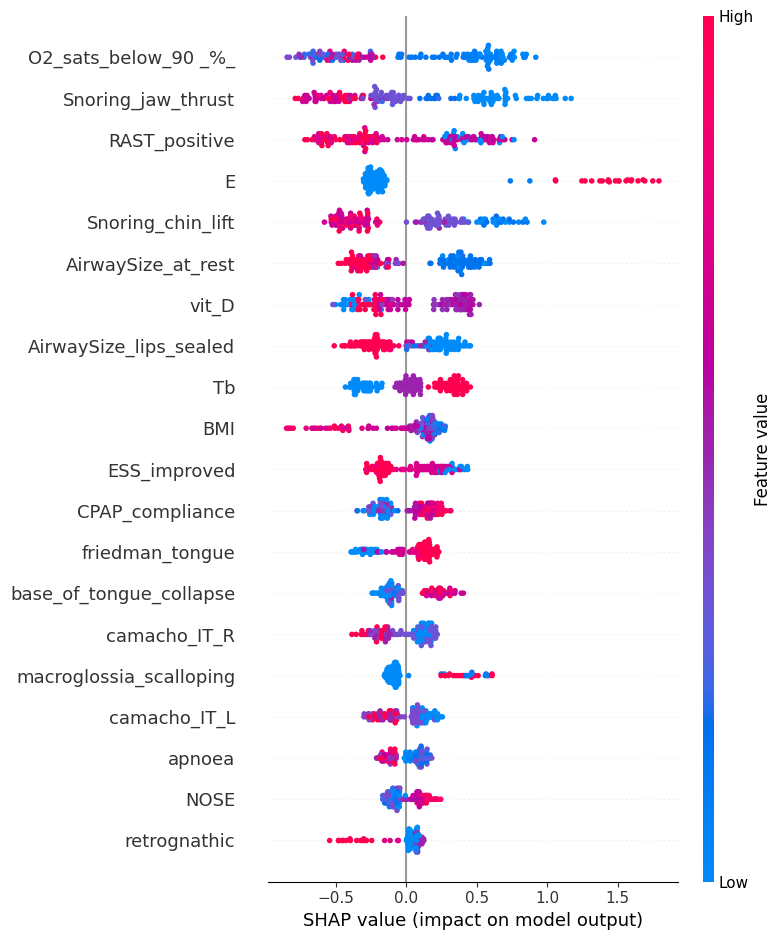

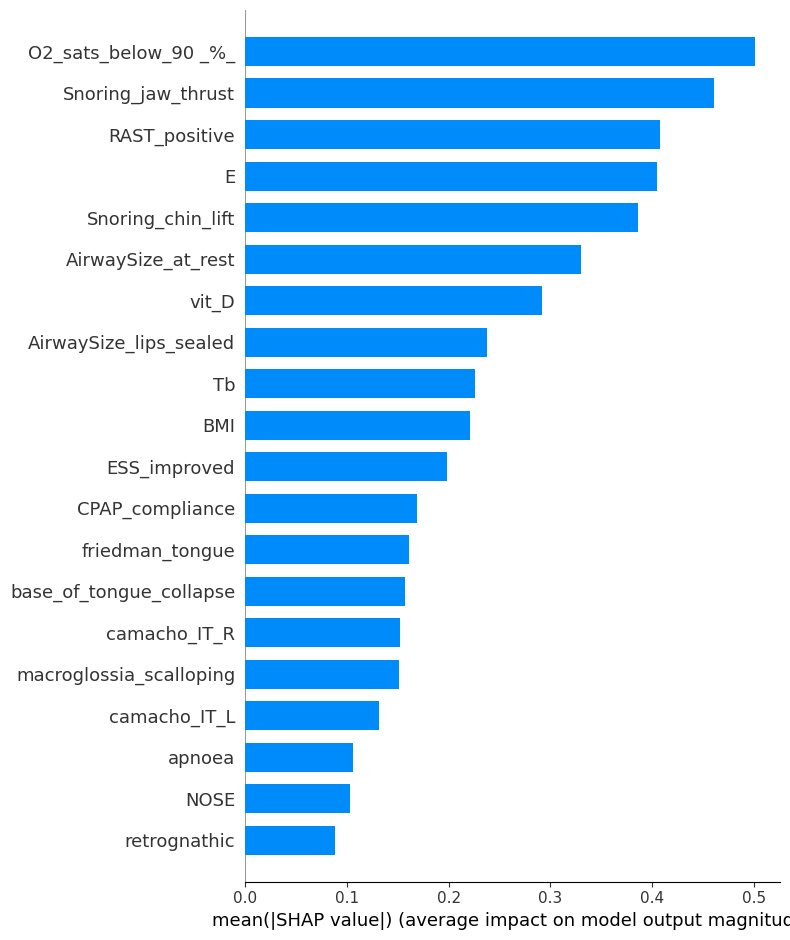

In [ ]:
treatment_to_visualize = 'MAD'
clf = models[treatment_to_visualize]
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_all_imputed)

# Beeswarm: each dot = one patient; x-position = SHAP value; colour = feature value
# This shows BOTH the direction and magnitude of each feature's impact
shap.summary_plot(shap_values, X_all_imputed, feature_names=available_features)

# Bar plot: mean |SHAP| — cleaner global feature importance view
shap.summary_plot(shap_values, X_all_imputed, feature_names=available_features, plot_type='bar')

In [ ]:
def predict_treatments(
    patient_dict,
    models,
    mice_imputer,
    available_features,
    probability_threshold=0.3,
    top_n_shap_reasons=3):
  patient_row = {feat: patient_dict.get(feat, np.nan) for feat in available_features}
  patient_df = pd.DataFrame([patient_row], columns=available_features)

  patient_imputed_array = mice_imputer.transform(patient_df)
  patient_imputed = pd.DataFrame(patient_imputed_array, columns=available_features)

  results = []

  for treatment, clf in models.items():
    prob = clf.predict_proba(patient_imputed)[0][1]
    if prob < probability_threshold:
      continue

    explainer = shap.TreeExplainer(clf)
    patient_shap = explainer.shap_values(patient_imputed)[0]

    # Sort features by |SHAP| to find most influential for this patient
    feature_shaps = sorted(
        zip(available_features, patient_shap),
        key=lambda x: abs(x[1]),
        reverse=True
        )

    reasons = []
    for feat, shap_val in feature_shaps[:top_n_shap_reasons]:
      feat_value = patient_imputed[feat].values[0]
      direction = "increases" if shap_val > 0 else "decreases"
      reasons.append(
          f"{feat}={feat_value:.2f} {direction} likelihood (SHAP={shap_val:+.3f})"
          )

    results.append({
        'treatment':   treatment,
        'probability': round(prob, 3),
        'reasons':     reasons
        })

    # Sort by probability descending — highest confidence recommendations first
    results.sort(key=lambda x: x['probability'], reverse=True)
  return results

In [ ]:
new_patient = {
    'BMI': 32.5, 'AHI': 28.0, 'ODI': 24.0, 'ESS': 14.0,
    'sAHI': 38.0, 'nsAHI': 12.0,
    'mean_o2 [%]': 94.0, 'O2_sats_below_90 [%]': 8.5,
    'lowest_O2(SS) [%]': 82.0, 'STOP_BANG': 5.0,
    'CPAP_compliance': 0.3, 'NOSE': 12.0, 'Insom': 8.0, 'RSI': 5.0,
    'Alc_units': 10.0, 'smoker': 0.0,
    'tonsils': 1.0, 'friedman_tongue': 2.0, 'uvula': 2.0,
    'oroph_crowding': 2.0, 'retrognathic': 1.0,
    'rhinitis': 2.0, 'DNS_present': 1.0, 'DNS_max_grade': 2.0,
    'macroglossia': 0.0, 'reflux': 1.0,
    'P': 3.0, 'T': 1.0, 'L': 0.0, 'Tb': 2.0, 'E': 0.0,
    'velopharyngeal_collapse': 3.0,
    'oropharyngeal_collapse': 1.0,
    'base_of_tongue_collapse': 2.0,
    'AirwaySize_jaw_thrust': 3.0, 'AirwaySize_chin_lift': 2.0,
    'Snoring_jaw_thrust': 0.0, 'Snoring_chin_lift': 1.0,
}

# Load saved artefacts
with open('treatment_models.pkl', 'rb') as f:
  models = pickle.load(f)
with open('mice_imputer.pkl', 'rb') as f:
  mice_imputer = pickle.load(f)

recommendations = predict_treatments(
    patient_dict=new_patient,
    models=models,
    mice_imputer=mice_imputer,
    available_features=available_features,
    probability_threshold=0.30,
    top_n_shap_reasons=3
)

print("=" * 70)
print("RECOMMENDED TREATMENTS (sorted by probability)")
print("=" * 70)
for rec in recommendations:
  print(f"\n  {rec['treatment']:40s}  P={rec['probability']:.1%}")
  for reason in rec['reasons']:
    print(f"    • {reason}")

RECOMMENDED TREATMENTS (sorted by probability)

  Weight Loss                               P=91.7%
    • BMI=32.50 increases likelihood (SHAP=+2.544)
    • friedman_tongue=2.00 decreases likelihood (SHAP=-0.547)
    • camacho_IT_L=2.70 increases likelihood (SHAP=+0.327)

  Rhinitis Rx                               P=85.5%
    • rhinitis=2.00 increases likelihood (SHAP=+1.143)
    • camacho_IT_L=2.70 increases likelihood (SHAP=+0.642)
    • epiglottis_grade=0.24 decreases likelihood (SHAP=-0.371)

  Barbed Suture                             P=82.1%
    • P=3.00 increases likelihood (SHAP=+0.748)
    • dental=0.35 increases likelihood (SHAP=+0.457)
    • pressure=12.01 decreases likelihood (SHAP=-0.391)

  Sleep Position Modifier                   P=81.3%
    • sAHI=38.00 increases likelihood (SHAP=+0.763)
    • O2_sats_below_90 _%_=19.66 decreases likelihood (SHAP=-0.535)
    • trapdoor_assessed=0.51 decreases likelihood (SHAP=-0.517)

  MAD                                       P=79.8

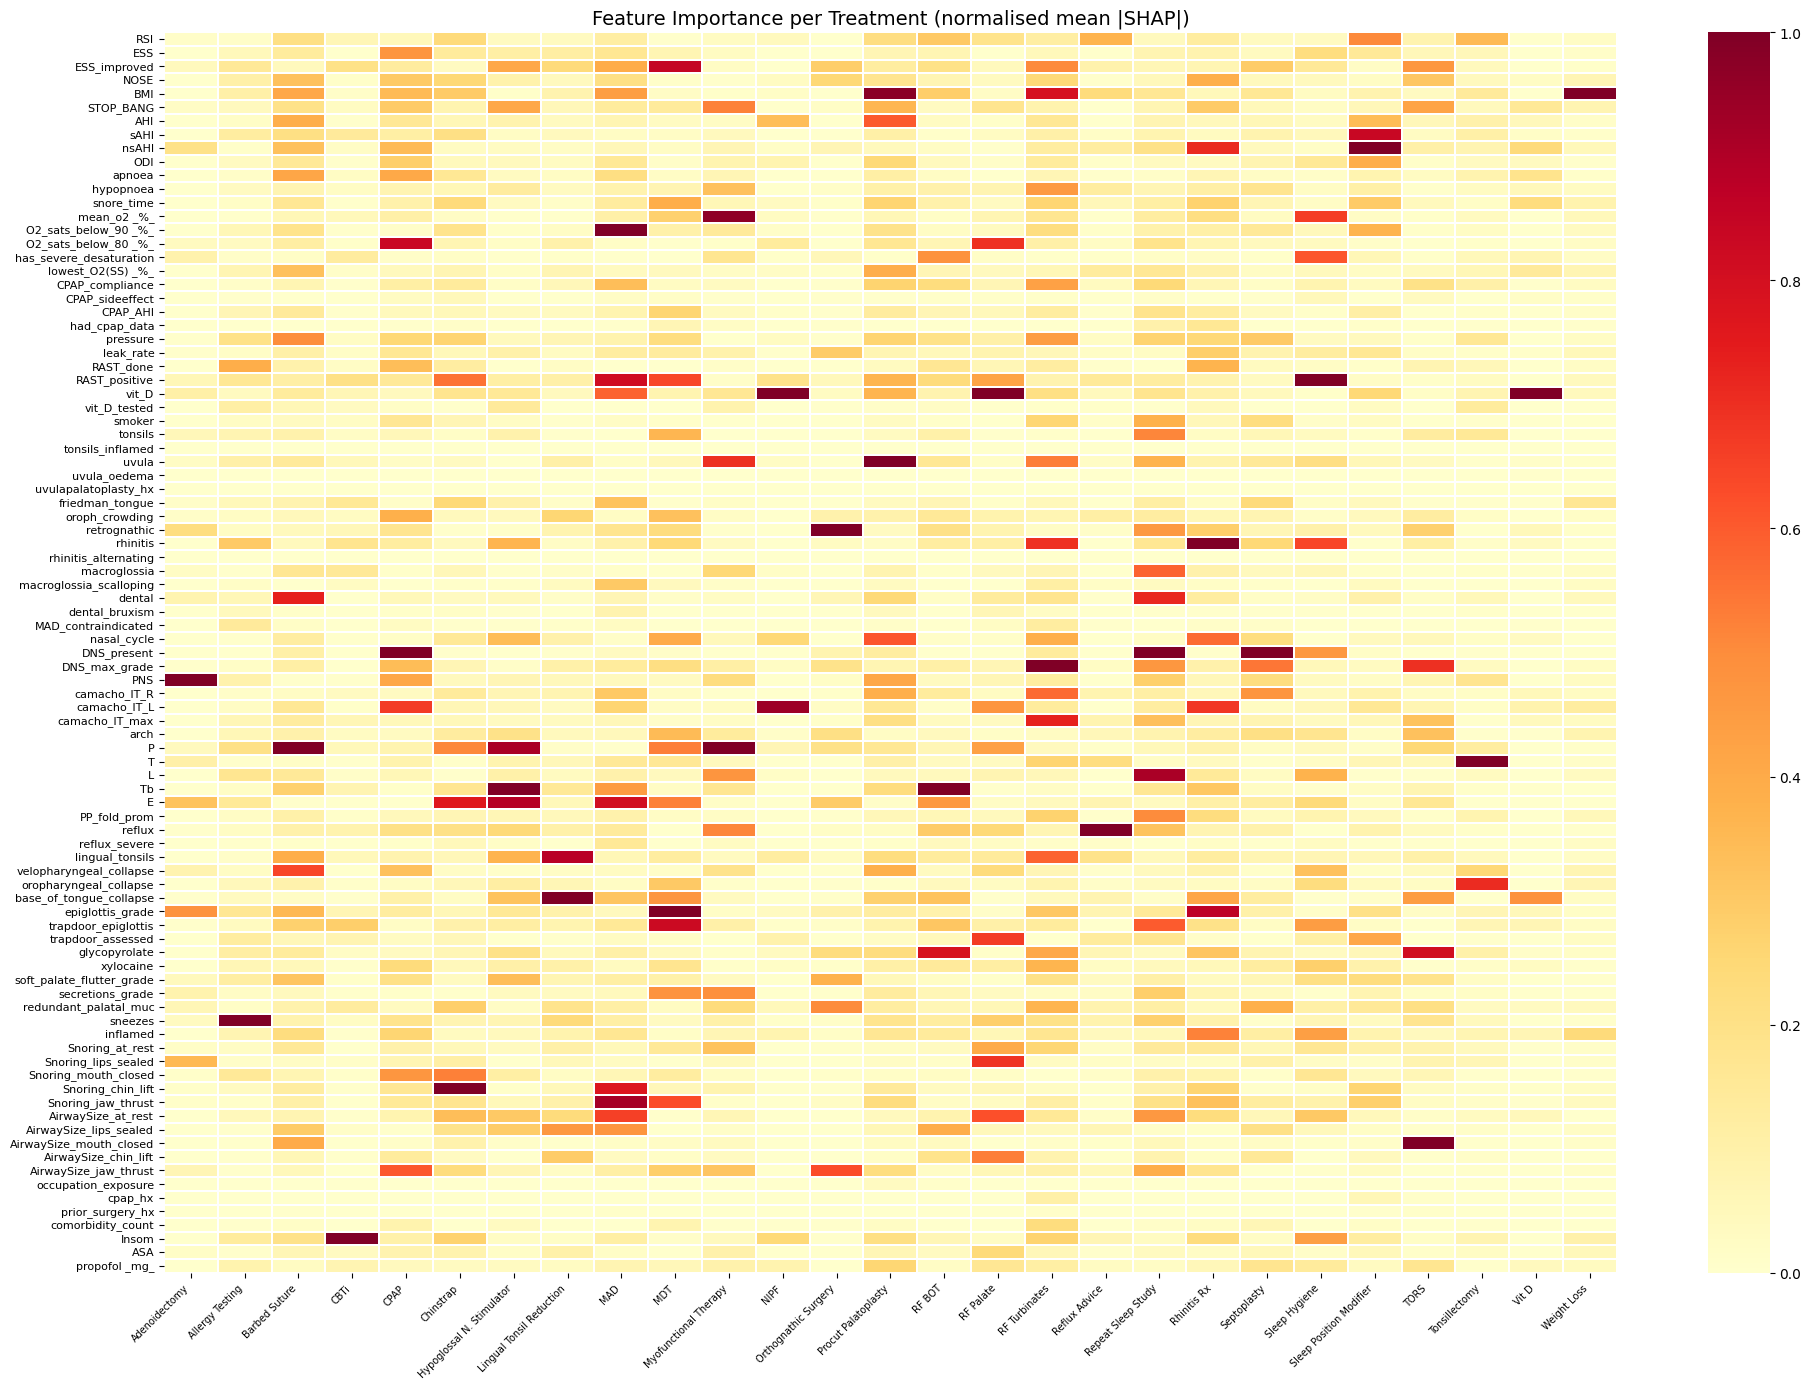

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Build DataFrame: rows = treatments, columns = features
shap_matrix = pd.DataFrame(shap_summaries).T

# Normalise per treatment (per row) so colours are comparable across treatments
shap_matrix_norm = shap_matrix.div(shap_matrix.max(axis=1), axis=0)

plt.figure(figsize=(20, 14))
sns.heatmap(
    shap_matrix_norm.T,
    cmap='YlOrRd',
    xticklabels=True,
    yticklabels=True,
    linewidths=0.3,
    annot=False
)
plt.title('Feature Importance per Treatment (normalised mean |SHAP|)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('shap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()